In [1]:
#Libraries

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pytesseract
import os

In [4]:
# Step 1: Load the original JPG image
img_jpg = cv2.imread(r"C:\Users\aayan\OneDrive\Desktop\Project\sc.png")

In [5]:
# Path to the directory
dir_path = r"C:\Users\aayan\OneDrive\Desktop\Project\new"

# Loop through all the files in the directory
for filename in os.listdir(dir_path):
    file_path = os.path.join(dir_path, filename)
    if os.path.isfile(file_path):
        os.remove(file_path)  # Delete the file

In [8]:
# Step 2: Save it as PNG
png_path = r"C:\Users\aayan\OneDrive\Desktop\Project\output_image.png"
cv2.imwrite(png_path, img_jpg)
if png_path is None:
    print("Error: Image not found or failed to load")

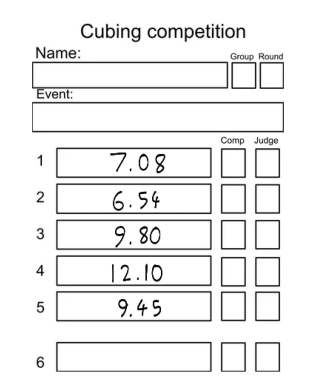

In [9]:
# Step 3: Reload the saved PNG image
img = cv2.imread(png_path)
plt.axis('off')
plt.imshow(img)

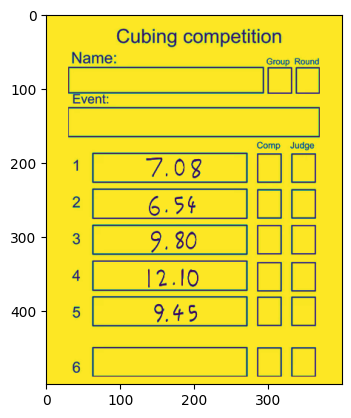

In [10]:
# Adaptive threshold to highlight boxes
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray)  


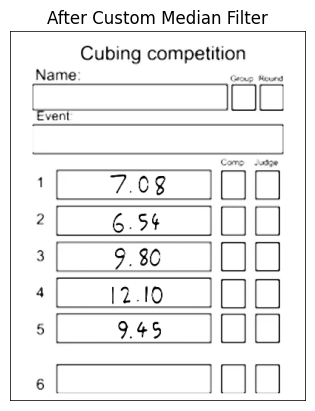

In [11]:
# Noise Reduction
img_noisy1 = gray
m, n = img_noisy1.shape
img_new1 = np.zeros([m, n])

for i in range(1, m - 1):
    for j in range(1, n - 1):
        temp = [
            img_noisy1[i-1, j-1], img_noisy1[i-1, j], img_noisy1[i-1, j+1],
            img_noisy1[i, j-1],   img_noisy1[i, j],   img_noisy1[i, j+1],
            img_noisy1[i+1, j-1], img_noisy1[i+1, j], img_noisy1[i+1, j+1]
        ]
        temp = sorted(temp)
        img_new1[i, j] = temp[4]  # median

img_new1 = img_new1.astype(np.uint8)

plt.imshow(img_new1, cmap='gray')
plt.title("After Custom Median Filter")
plt.axis('off')
plt.show()

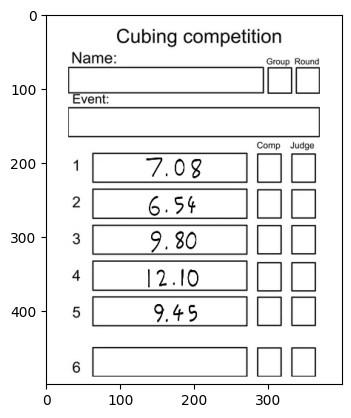

In [25]:

clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
gray_clahe = clahe.apply(img_new1)

blur = cv2.GaussianBlur(gray_clahe, (7, 7), 0)


thresh = cv2.adaptiveThreshold(blur, 255, 
                               cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                               cv2.THRESH_BINARY_INV, 
                               15, 3)  # Try 15 and 3 instead of 11 and 2

#Remove noise
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
morph = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=1)



plt.imshow(img)  

In [13]:
# Find contours
contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [14]:
# Filter contours by area and aspect ratio
rects = []
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    area = w * h
    aspect_ratio = w / float(h)

    if 1000 < area < 15000 and 2.0 < aspect_ratio < 6.0:
        rects.append((x, y, w, h))

In [15]:
# Sort boxes from top to bottom
rects = sorted(rects, key=lambda r: r[1])

In [16]:
# Draw rectangles on a copy
img_copy = thresh
for (x, y, w, h) in rects:
    cv2.rectangle(img_copy, (x, y), (x + w, y + h), (0, 255, 0), 2)
    
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 200:  # Tune this threshold
        cv2.drawContours(img_copy, [cnt], -1, (0, 255, 0), 2)


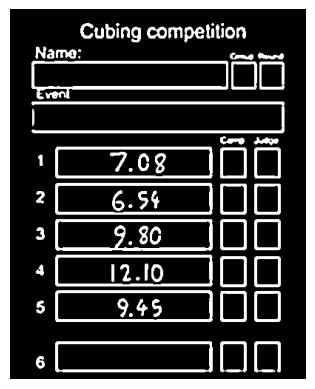

In [17]:
# Show or save the result
cv2.imwrite("/mnt/data/detected_boxes.png", img_copy)
plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [18]:
# Indices which are not needed
# skip_indices = [0,1,2,3,9]
save_index = 1  # This controls the output filename starting from 1.png

# Re-crop and save only the selected boxes
for i, (x, y, w, h) in enumerate(rects):
#     if i in skip_indices:
#         print(f"Skipped: Box {i+1}")
#         continue

    cropped = img[y:y+h, x:x+w]
    save_path = rf"C:\Users\aayan\OneDrive\Desktop\Pjt\new\{save_index}.png"
    cv2.imwrite(save_path, cropped)
    print(f"Saved: {save_path}")
    save_index += 1


In [19]:
# Skip indices 0 and 6 (1st and 7th box)
display_index = 1  # for naming Solve Time 1 to 5

for i, (x, y, w, h) in enumerate(rects):
#     if i in skip_indices:
#         continue
    
    cropped = img[y:y+h, x:x+w]
    plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
    plt.title(f"Solve Time {display_index}")
    plt.axis('off')
    plt.show()
    
    display_index += 1


In [20]:
ocr_results = []

# Loop over each cropped box
for i in range(5):
    path = rf"C:\Users\aayan\OneDrive\Desktop\Pjt\new\{i+1}.png"
    
    img_crop = cv2.imread(path)

    if img_crop is None:
        print(f"Image not found: {path}")
        continue  # <-- only continue if image is not found

    text = pytesseract.image_to_string(img_crop)
    cleaned_text = text.strip().replace("\n", "")
    ocr_results.append(cleaned_text)

    print(f"Solve {i+1}: {cleaned_text}")

Image not found: C:\Users\aayan\OneDrive\Desktop\Pjt\new\1.png
Image not found: C:\Users\aayan\OneDrive\Desktop\Pjt\new\2.png
Image not found: C:\Users\aayan\OneDrive\Desktop\Pjt\new\3.png
Image not found: C:\Users\aayan\OneDrive\Desktop\Pjt\new\4.png
Image not found: C:\Users\aayan\OneDrive\Desktop\Pjt\new\5.png


In [21]:
print(ocr_results)

[]


In [22]:
import re

def time_str_to_seconds(t):
    t = t.strip().replace(',', '.').replace(" ", "")

    # Allow only digits, colon, and dot
    t = re.sub(r'[^0-9:.]', '', t)

    if t.isdigit():
        if len(t) == 3:
            t = f"{t[0]}.{t[1:]}"  # 1.23
        elif len(t) == 4:
            t = f"{t[:2]}.{t[2:]}"  # 12.34
        elif len(t) == 5:
            t = f"{t[:2]}:{t[2:4]}.{t[4]}0"  # 12:34.50
        elif len(t) == 6:
            t = f"{t[:2]}:{t[2:4]}.{t[4:]}"  # 12:34.56

    if ':' in t:
        mins, secs = t.split(':')
        return float(mins) * 60 + float(secs)
    
    return float(t)


In [23]:
num_array = []

for x in ocr_results:
    try:
        seconds = time_str_to_seconds(x)
        num_array.append(seconds)
    except ValueError:
        print(f"Skipped invalid entry: {x}")
print(num_array)

[]


In [24]:
def format_result_time(t):
    if t >= 60:
        mins = int(t // 60)
        secs = t % 60
        return f"{mins}:{secs:05.2f}"  # Ensures 2 digits after dot and leading zero if needed
    else:
        return f"{t:.2f}"

# Convert OCR results to float and clean any invalid entries
times = []
for t in num_array:
    try:
        times.append(time_str_to_seconds(str(t)))  # Ensure t is a string
    except ValueError:
        print(f"Invalid time skipped: {t}")

else:
    solves = times
    sorted_times = sorted(times)
    
    best = sorted_times[0]
    worst = sorted_times[-1]
    avg = round(sum(sorted_times[1:-1]) / 3, 2)

    print("Solves:", ", ".join([format_result_time(t) for t in solves]))
    print(f"Best: {format_result_time(best)}")
    print(f"Worst: {format_result_time(worst)}")
    print(f"WCA Average: {format_result_time(avg)}")



IndexError: list index out of range